## Code

  Abhishek V Ammanagi  |  2023BCSE07AED500
  Experiment 5: RNN Temperature Prediction
Train seqs: 376 | Test seqs: 94


c:\Users\manju\anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.2316 - mae: 0.3097 - val_loss: 0.0074 - val_mae: 0.0755
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0250 - mae: 0.1268 - val_loss: 0.0055 - val_mae: 0.0575
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0107 - mae: 0.0846 - val_loss: 0.0052 - val_mae: 0.0576
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0068 - mae: 0.0659 - val_loss: 0.0051 - val_mae: 0.0567
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0060 - mae: 0.0624 - val_loss: 0.0047 - val_mae: 0.0556
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 - mae: 0.0592 - val_loss: 0.0046 - val_mae: 0.0573
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0055 - mae: 0.0586 - val_loss: 0.0045 - val_mae: 0.0549
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - mae: 0.0554 - val_loss: 0.0048 - val_mae: 0.0556
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.005

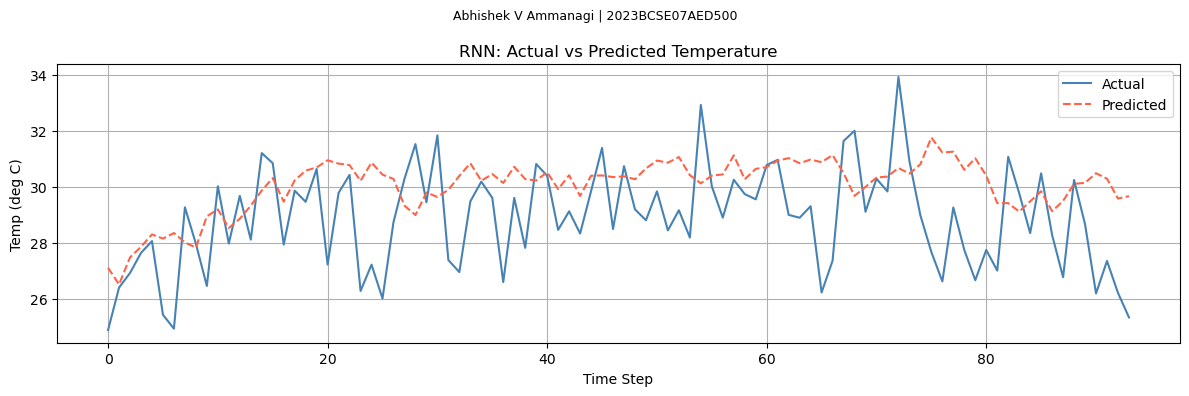

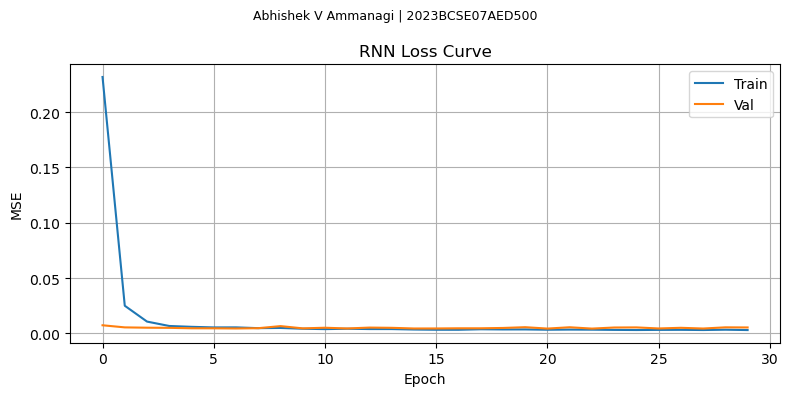

Abhishek V Ammanagi | 2023BCSE07AED500


In [1]:
# Experiment 5 – RNN Temperature Prediction
# Abhishek V Ammanagi | 2023BCSE07AED500

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 55)
print("  Abhishek V Ammanagi  |  2023BCSE07AED500")
print("  Experiment 5: RNN Temperature Prediction")
print("=" * 55)

np.random.seed(42)
time = np.arange(500)
temp = 20 + 10*np.sin(2*np.pi*time/365) + np.random.normal(0,1.5,500)

scaler    = MinMaxScaler()
temp_norm = scaler.fit_transform(temp.reshape(-1,1)).flatten()
SEQ_LEN   = 30

def make_seq(data, sl):
    X, y = [], []
    for i in range(len(data)-sl):
        X.append(data[i:i+sl]); y.append(data[i+sl])
    return np.array(X), np.array(y)

X, y  = make_seq(temp_norm, SEQ_LEN)
X     = X.reshape(-1, SEQ_LEN, 1)
sp    = int(0.8*len(X))
X_tr, X_te = X[:sp], X[sp:]
y_tr, y_te = y[:sp], y[sp:]
print(f"Train seqs: {X_tr.shape[0]} | Test seqs: {X_te.shape[0]}")

model = models.Sequential([
    layers.SimpleRNN(64, input_shape=(SEQ_LEN,1), return_sequences=True),
    layers.SimpleRNN(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30, batch_size=32,
                    validation_split=0.1, verbose=1)

y_pred_n = model.predict(X_te).flatten()
y_pred   = scaler.inverse_transform(y_pred_n.reshape(-1,1)).flatten()
y_actual = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()

mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
print(f"\nMAE  : {mae:.4f} deg C")
print(f"RMSE : {rmse:.4f} deg C")

plt.figure(figsize=(12,4))
plt.plot(y_actual, label='Actual',    color='steelblue')
plt.plot(y_pred,   label='Predicted', color='tomato', linestyle='--')
plt.title('RNN: Actual vs Predicted Temperature')
plt.xlabel('Time Step'); plt.ylabel('Temp (deg C)')
plt.legend(); plt.grid(True)
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500", fontsize=9)
plt.tight_layout(); plt.savefig('exp5_pred.png',dpi=300); plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('RNN Loss Curve')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.legend(); plt.grid(True)
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500", fontsize=9)
plt.tight_layout(); plt.savefig('exp5_loss.png',dpi=300); plt.show()
print("Abhishek V Ammanagi | 2023BCSE07AED500")


## Result
_Run the cell above and paste your observations here._